# Flight Delay Visualization

This notebook loads the processed flight delay dataset and builds a more operationally focused airline analytics dashboard.
We improve chart robustness, compare mean vs median, add sample sizes, and explain business implications for delay management.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.style.use('seaborn-v0_8-whitegrid')

csv_path = '../data/processed_flight_data.csv'
df = pd.read_csv(csv_path)

# Standardize key columns and ensure numeric delay values.
df['Month'] = pd.to_numeric(df['Month'], errors='coerce').astype('Int64')
df['ArrDelay'] = pd.to_numeric(df['ArrDelay'], errors='coerce')
df['DepDelay'] = pd.to_numeric(df.get('DepDelay', pd.Series(dtype='float64')), errors='coerce')

if 'DepHour' not in df.columns:
    if 'DepTime' in df.columns:
        dep_time = pd.to_numeric(df['DepTime'], errors='coerce').fillna(0).astype(int)
        df['DepHour'] = (dep_time // 100).clip(lower=0, upper=23)
    else:
        raise ValueError('Dataset must contain DepHour or DepTime.')

# Reconstruct carrier labels from one-hot columns if needed.
carrier_cols = [col for col in df.columns if col.startswith('UniqueCarrier_')]
if carrier_cols:
    df['Carrier'] = df[carrier_cols].idxmax(axis=1).str.replace('UniqueCarrier_', '', regex=False)

# Identify available delay cause columns.
delay_cause_cols = [c for c in ['WeatherDelay', 'CarrierDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'] if c in df.columns]
for col in delay_cause_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Utility functions for plotting.
def save_fig(fig, name):
    fig.savefig(f'../images/{name}.png', dpi=150, bbox_inches='tight')


def annotate_bars(ax, labels=None, fmt='{:.0f}', position='center'):
    for idx, patch in enumerate(ax.patches):
        height = patch.get_height()
        if height is None or height != height:
            continue
        ax.annotate(fmt.format(height),
                    xy=(patch.get_x() + patch.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)


def format_thousands(x, pos):
    return f'{int(x):,}'

print('Loaded dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Delay cause columns detected:', delay_cause_cols)

Loaded dataset shape: (1868454, 46)
Columns: ['Unnamed: 0', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'ArrTime', 'CRSElapsedTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'CancellationCode', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay', 'UniqueCarrier_AA', 'UniqueCarrier_AQ', 'UniqueCarrier_AS', 'UniqueCarrier_B6', 'UniqueCarrier_CO', 'UniqueCarrier_DL', 'UniqueCarrier_EV', 'UniqueCarrier_F9', 'UniqueCarrier_FL', 'UniqueCarrier_HA', 'UniqueCarrier_MQ', 'UniqueCarrier_NW', 'UniqueCarrier_OH', 'UniqueCarrier_OO', 'UniqueCarrier_UA', 'UniqueCarrier_US', 'UniqueCarrier_WN', 'UniqueCarrier_XE', 'UniqueCarrier_YV', 'Origin_Freq', 'Dest_Freq', 'DepHour', 'IsWeekend', 'IsRushHour', 'FlightPeriod', 'Carrier']
Delay cause columns detected: ['WeatherDelay', 'CarrierDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']


## Airline delay performance: Mean vs Median

This section compares average and median arrival delays for each carrier. We include flight volume to surface reliability issues and outlier sensitivity.

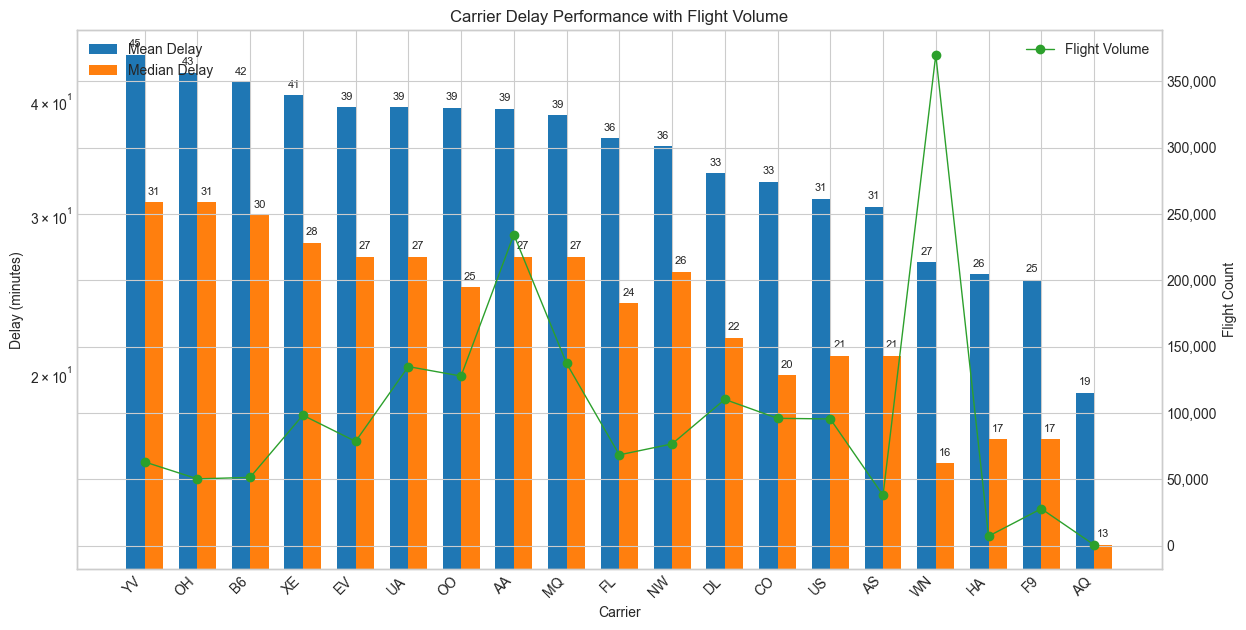

In [10]:
carrier_stats = (
    df[['Carrier', 'ArrDelay']]
    .dropna(subset=['Carrier', 'ArrDelay'])
    .groupby('Carrier')
    .agg(mean_delay=('ArrDelay', 'mean'), median_delay=('ArrDelay', 'median'), flights=('ArrDelay', 'count'))
    .sort_values('mean_delay', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 7))
indices = range(len(carrier_stats))
bar_width = 0.35
ax.bar([i - bar_width / 2 for i in indices], carrier_stats['mean_delay'], width=bar_width, label='Mean Delay', color='tab:blue')
ax.bar([i + bar_width / 2 for i in indices], carrier_stats['median_delay'], width=bar_width, label='Median Delay', color='tab:orange')
ax2 = ax.twinx()
ax2.plot(indices, carrier_stats['flights'], color='tab:green', marker='o', linewidth=1, label='Flight Volume')

ax.set_xticks(indices)
ax.set_xticklabels(carrier_stats.index, rotation=45, ha='right')
ax.set_title('Carrier Delay Performance with Flight Volume')
ax.set_xlabel('Carrier')
ax.set_ylabel('Delay (minutes)')
ax2.set_ylabel('Flight Count')
ax.set_yscale('log')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax2.yaxis.set_major_formatter(FuncFormatter(format_thousands))
annotate_bars(ax)
save_fig(fig, 'carrier_delay_mean_median')
plt.show()

**Insight:** Differences between mean and median delays reveal the impact of extreme delay events. Carriers with a large gap likely have sporadic outliers or occasional operational disruptions despite a generally stable schedule.

## Seasonal trends by airline

A heatmap helps identify which carriers see the worst delays in each month, revealing seasonal concentration patterns.

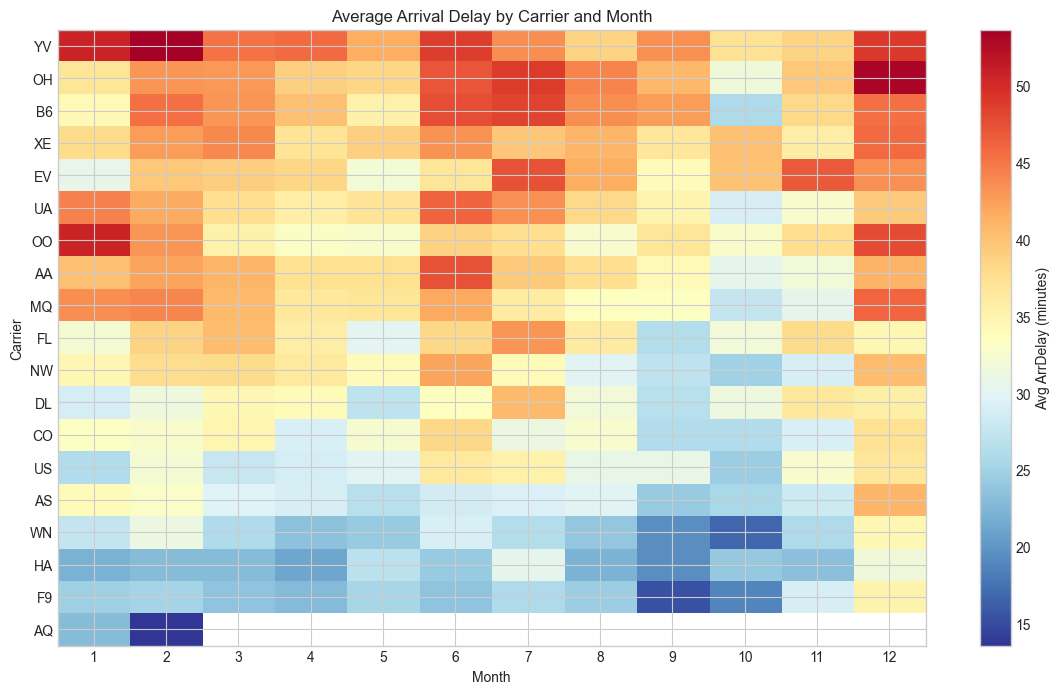

In [11]:
seasonal_heat = (
    df[['Carrier', 'Month', 'ArrDelay']]
    .dropna(subset=['Carrier', 'Month', 'ArrDelay'])
    .groupby(['Carrier', 'Month'], as_index=False)
    .mean()
)
seasonal_pivot = seasonal_heat.pivot(index='Carrier', columns='Month', values='ArrDelay').reindex(index=carrier_stats.index)

fig, ax = plt.subplots(figsize=(14, 8))
c = ax.imshow(seasonal_pivot, aspect='auto', cmap='RdYlBu_r', vmin=seasonal_pivot.min().min(), vmax=seasonal_pivot.max().max())
ax.set_xticks(range(12))
ax.set_xticklabels(range(1, 13))
ax.set_yticks(range(len(seasonal_pivot.index)))
ax.set_yticklabels(seasonal_pivot.index)
ax.set_xlabel('Month')
ax.set_ylabel('Carrier')
ax.set_title('Average Arrival Delay by Carrier and Month')
fig.colorbar(c, ax=ax, label='Avg ArrDelay (minutes)')
save_fig(fig, 'carrier_month_delay_heatmap')
plt.show()

**Insight:** Some carriers show strong seasonality, with delays concentrated in summer or winter. This can guide airline-specific capacity planning, crew flexibility, and seasonal buffer allocation.

## Monthly delay distribution and propagation

This section compares mean and median monthly delays and highlights how departure hour and departure delay propagate to arrival delay.

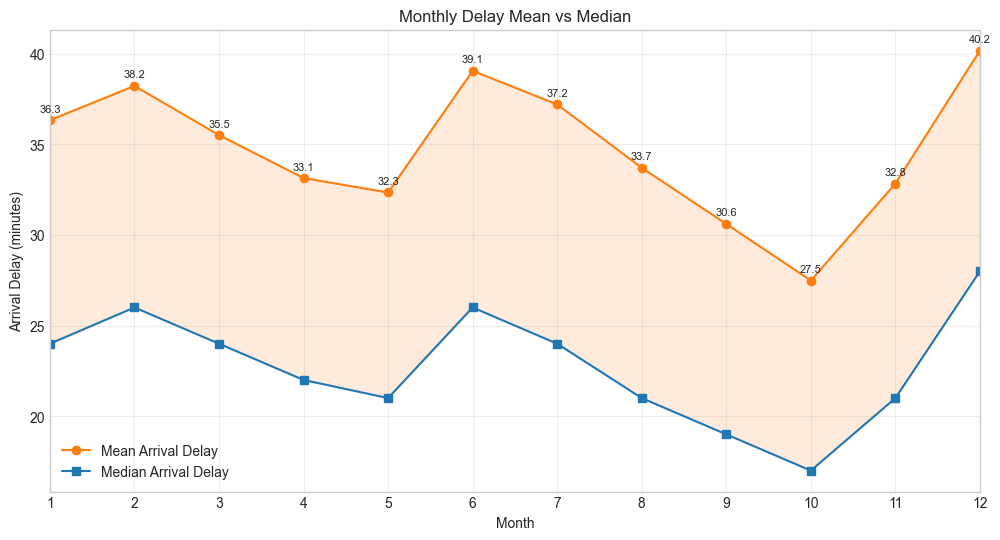

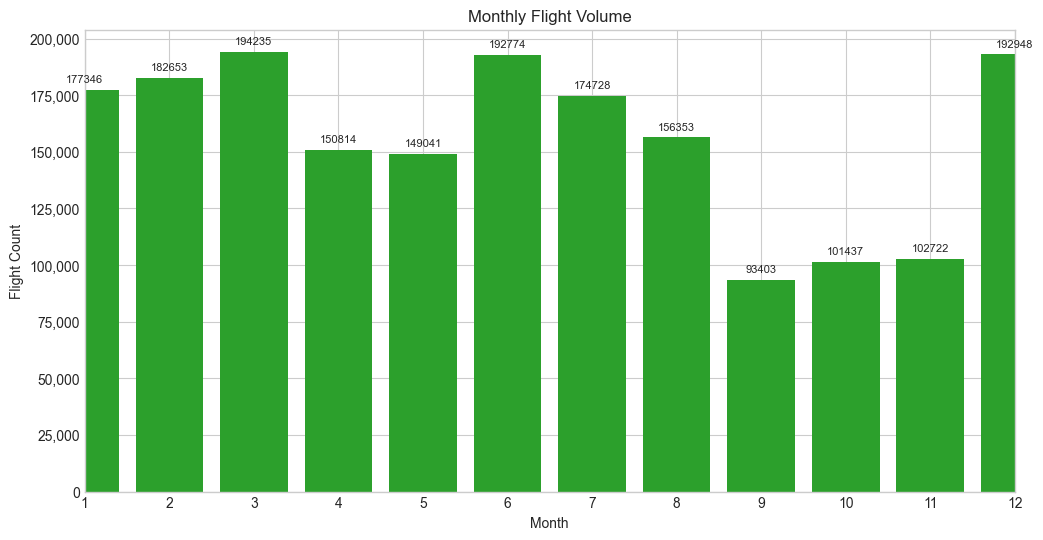

In [12]:
monthly_stats = (
    df[['Month', 'ArrDelay']]
    .dropna(subset=['Month', 'ArrDelay'])
    .groupby('Month')
    .agg(mean_delay=('ArrDelay', 'mean'), median_delay=('ArrDelay', 'median'), flights=('ArrDelay', 'count'))
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(monthly_stats.index, monthly_stats['mean_delay'], marker='o', label='Mean Arrival Delay', color='tab:orange')
ax.plot(monthly_stats.index, monthly_stats['median_delay'], marker='s', label='Median Arrival Delay', color='tab:blue')
ax.fill_between(monthly_stats.index, monthly_stats['mean_delay'], monthly_stats['median_delay'], color='tab:orange', alpha=0.15)
ax.set_title('Monthly Delay Mean vs Median')
ax.set_xlabel('Month')
ax.set_ylabel('Arrival Delay (minutes)')
ax.set_xticks(range(1, 13))
ax.set_xlim(1, 12)
ax.legend()
ax.grid(True, alpha=0.35)
for month, mean_val in zip(monthly_stats.index, monthly_stats['mean_delay']):
    ax.annotate(f'{mean_val:.1f}', xy=(month, mean_val), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=8)
save_fig(fig, 'monthly_delay_mean_vs_median')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
flight_counts = monthly_stats['flights']
ax.bar(monthly_stats.index, flight_counts, color='tab:green')
ax.set_title('Monthly Flight Volume')
ax.set_xlabel('Month')
ax.set_ylabel('Flight Count')
ax.set_xticks(range(1, 13))
ax.set_xlim(1, 12)
ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
annotate_bars(ax)
save_fig(fig, 'monthly_flight_volume')
plt.show()

**Insight:** The gap between mean and median in specific months indicates a greater frequency of large-delay events. Combining delay trends with flight volume helps decide whether seasonal capacity or weather mitigation is the main driver.

## Hourly delay propagation and congestion patterns

We now examine how departure hour relates to arrival delay and identify propagation risks across the day.

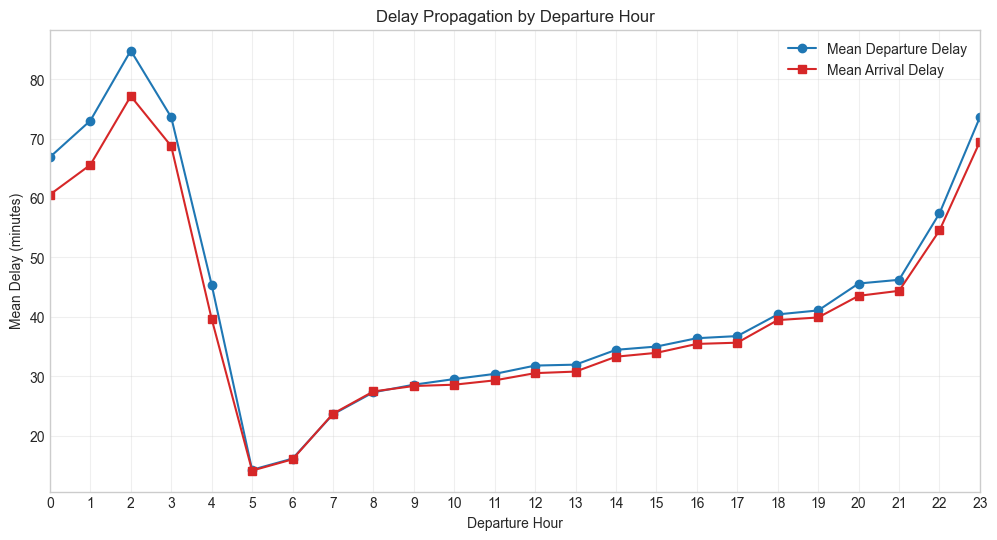

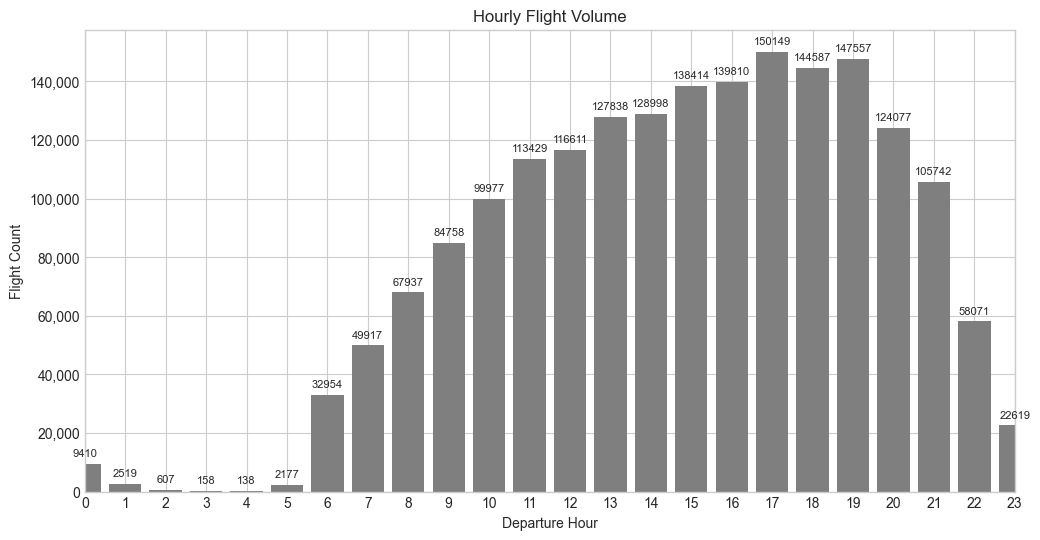

In [13]:
hourly_stats = (
    df[['DepHour', 'DepDelay', 'ArrDelay']]
    .dropna(subset=['DepHour', 'ArrDelay'])
    .groupby('DepHour')
    .agg(mean_dep_delay=('DepDelay', 'mean'), mean_arr_delay=('ArrDelay', 'mean'), flights=('ArrDelay', 'count'))
    .reindex(range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hourly_stats.index, hourly_stats['mean_dep_delay'], marker='o', label='Mean Departure Delay', color='tab:blue')
ax.plot(hourly_stats.index, hourly_stats['mean_arr_delay'], marker='s', label='Mean Arrival Delay', color='tab:red')
ax.set_title('Delay Propagation by Departure Hour')
ax.set_xlabel('Departure Hour')
ax.set_ylabel('Mean Delay (minutes)')
ax.set_xticks(range(0, 24))
ax.set_xlim(0, 23)
ax.legend()
ax.grid(True, alpha=0.3)
save_fig(fig, 'delay_propagation_by_hour')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(hourly_stats.index, hourly_stats['flights'], color='tab:gray')
ax.set_title('Hourly Flight Volume')
ax.set_xlabel('Departure Hour')
ax.set_ylabel('Flight Count')
ax.set_xticks(range(0, 24))
ax.set_xlim(0, 23)
ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
annotate_bars(ax)
save_fig(fig, 'hourly_flight_volume')
plt.show()

**Insight:** Morning and evening peaks often have higher delay propagation because delays compound over tightly spaced waves. Identifying these windows enables targeted buffer time and dispatching resources for recovery flights.

## Hour vs Month Delay Heatmap

This heatmap reveals how the delay profile changes across the year by departure hour.

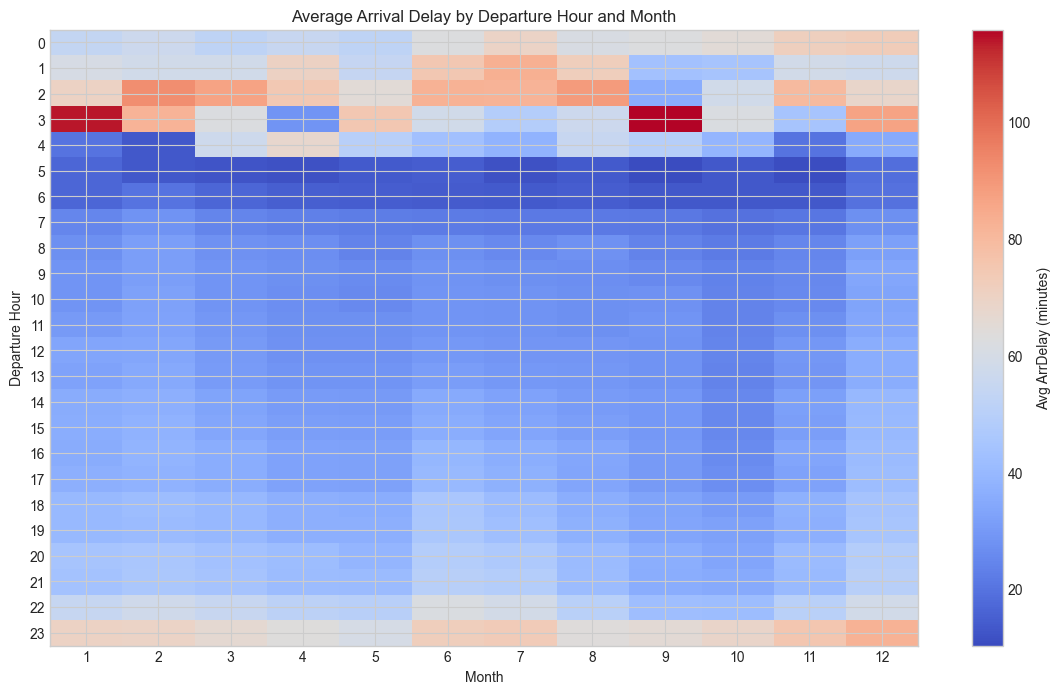

In [14]:
hour_month = (
    df[['DepHour', 'Month', 'ArrDelay']]
    .dropna(subset=['DepHour', 'Month', 'ArrDelay'])
    .groupby(['DepHour', 'Month'], as_index=False)
    .mean()
    .pivot(index='DepHour', columns='Month', values='ArrDelay')
    .reindex(index=range(24), columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(14, 8))
c = ax.imshow(hour_month, aspect='auto', cmap='coolwarm', vmin=hour_month.min().min(), vmax=hour_month.max().max())
ax.set_xticks(range(12))
ax.set_xticklabels(range(1, 13))
ax.set_yticks(range(24))
ax.set_yticklabels(range(24))
ax.set_xlabel('Month')
ax.set_ylabel('Departure Hour')
ax.set_title('Average Arrival Delay by Departure Hour and Month')
fig.colorbar(c, ax=ax, label='Avg ArrDelay (minutes)')
save_fig(fig, 'hour_month_delay_heatmap')
plt.show()

**Insight:** Hourly seasonality signals when airport waves are most vulnerable to delays. This helps operations teams prioritize de-icing, ground handling or airspace coordination in critical months and hours.

## Flight traffic vs delay relationship

This scatter plot compares airport traffic and delay exposure, highlighting whether high-volume hubs also carry higher average delays.

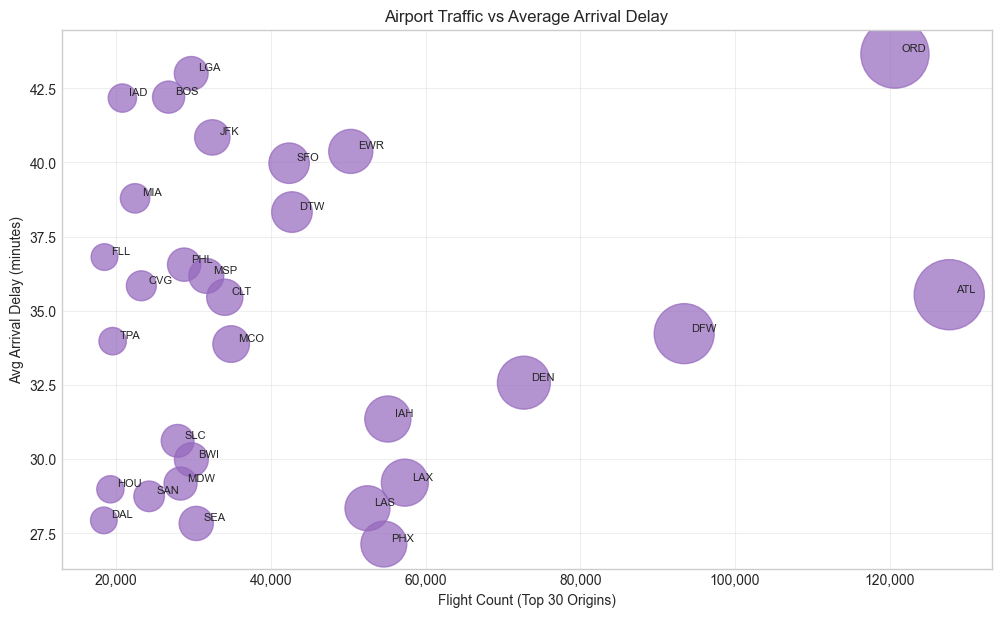

In [15]:
airport_stats = (
    df[['Origin', 'ArrDelay']]
    .dropna(subset=['Origin', 'ArrDelay'])
    .groupby('Origin')
    .agg(flights=('ArrDelay', 'count'), avg_delay=('ArrDelay', 'mean'))
    .sort_values('flights', ascending=False)
    .reset_index()
)

top_airports = airport_stats.head(30)
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(top_airports['flights'], top_airports['avg_delay'], s=top_airports['flights'] / 50, alpha=0.7, color='tab:purple')
for _, row in top_airports.iterrows():
    ax.annotate(row['Origin'], xy=(row['flights'], row['avg_delay']), xytext=(5, 2), textcoords='offset points', fontsize=8)
ax.set_title('Airport Traffic vs Average Arrival Delay')
ax.set_xlabel('Flight Count (Top 30 Origins)')
ax.set_ylabel('Avg Arrival Delay (minutes)')
ax.xaxis.set_major_formatter(FuncFormatter(format_thousands))
ax.grid(True, alpha=0.3)
save_fig(fig, 'airport_traffic_vs_delay')
plt.show()

**Insight:** Large hubs can still deliver low average delay if operations are well-managed. Airports with both high volume and high delay are priority candidates for capacity or process improvement.

## Cancellation trends by month, airline, and airport

We expand cancellation coverage to reveal where disruptions are concentrated in the network.

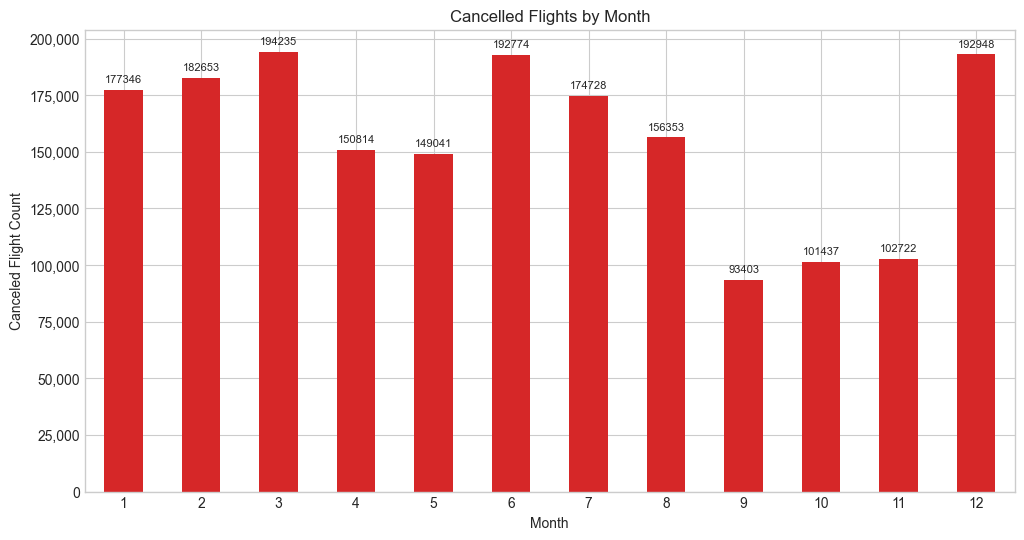

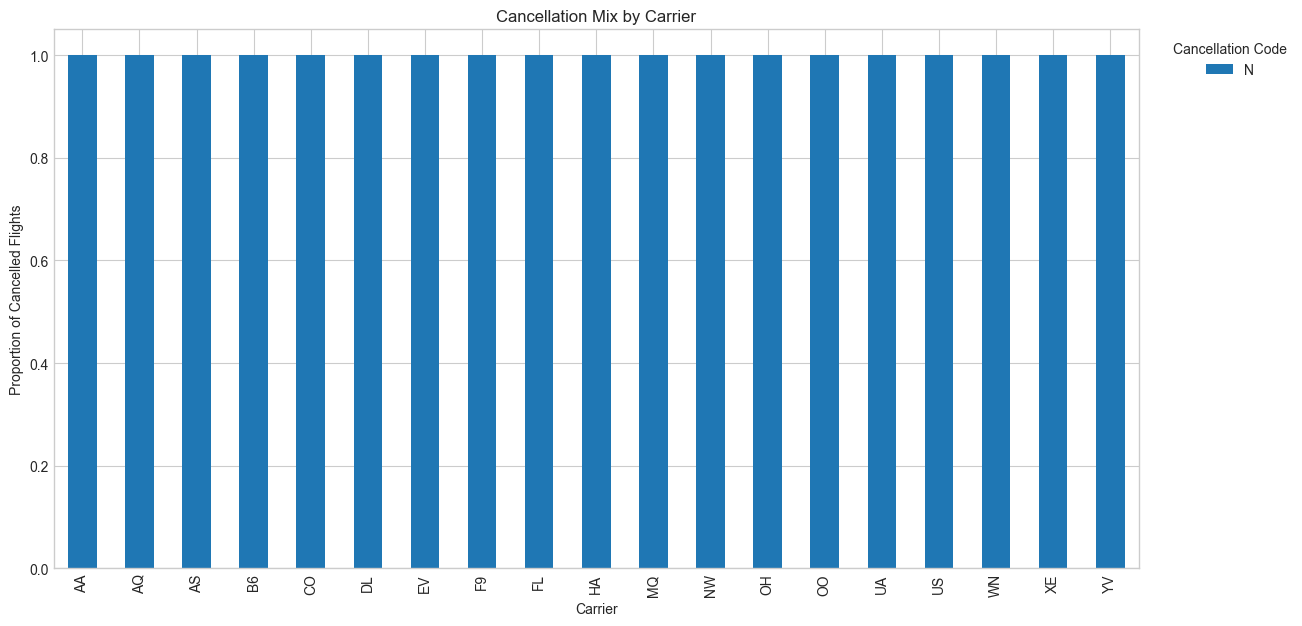

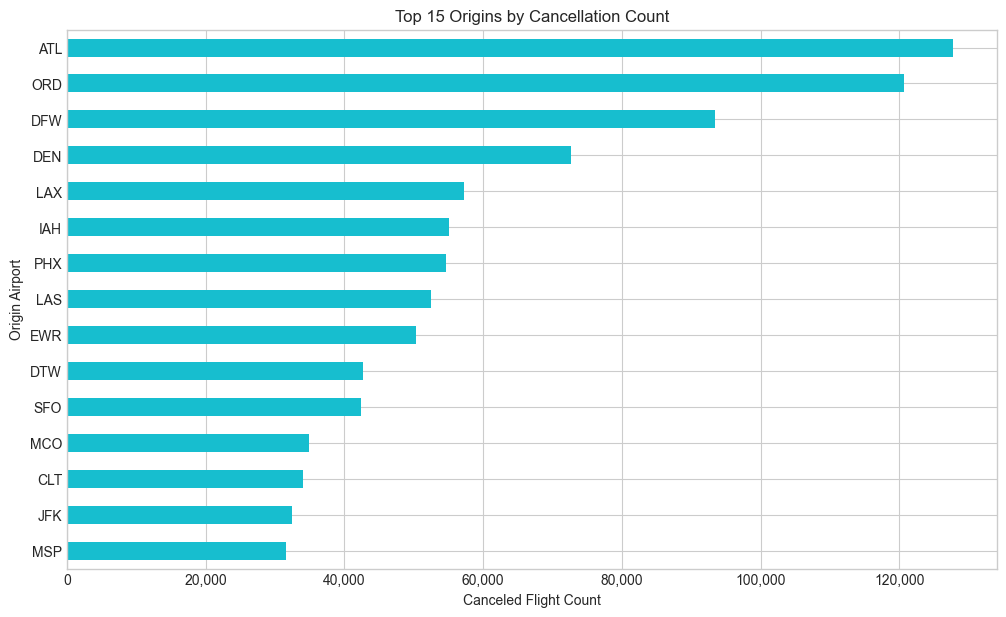

In [16]:
cancel_mon = (
    df['CancellationCode']
    .fillna('Unknown')
    .groupby(df['Month'])
    .value_counts()
    .unstack(fill_value=0)
    .reindex(range(1, 13), fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))
cancel_mon.sum(axis=1).plot(kind='bar', color='tab:red', ax=ax)
ax.set_title('Cancelled Flights by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Canceled Flight Count')
ax.set_xticklabels(range(1, 13), rotation=0)
ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))
annotate_bars(ax)
save_fig(fig, 'cancellations_by_month')
plt.show()

carrier_cancel = (
    df[['Carrier', 'CancellationCode']]
    .copy()
    .fillna({'CancellationCode': 'Unknown'})
    .groupby(['Carrier', 'CancellationCode'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 7))
carrier_cancel.div(carrier_cancel.sum(axis=1), axis=0).fillna(0).plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Cancellation Mix by Carrier')
ax.set_xlabel('Carrier')
ax.set_ylabel('Proportion of Cancelled Flights')
ax.legend(title='Cancellation Code', bbox_to_anchor=(1.02, 1), loc='upper left')
save_fig(fig, 'cancellations_by_carrier')
plt.show()

airport_cancel = (
    df[['Origin', 'CancellationCode']]
    .copy()
    .fillna({'CancellationCode': 'Unknown'})
    .groupby(['Origin', 'CancellationCode'])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .sort_values('total', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
airport_cancel[['total']].sort_values('total').plot(kind='barh', ax=ax, color='tab:cyan', legend=False)
ax.set_title('Top 15 Origins by Cancellation Count')
ax.set_xlabel('Canceled Flight Count')
ax.set_ylabel('Origin Airport')
ax.xaxis.set_major_formatter(FuncFormatter(format_thousands))
save_fig(fig, 'cancellations_by_airport')
plt.show()

**Insight:** Cancellations may surge seasonally or concentrate on specific carriers and airports. This helps identify whether the disruption is network-wide, carrier-specific, or driven by particular origin hubs.

## Delay cause analysis

We compare underlying delay causes and highlight which drivers dominate average delay.

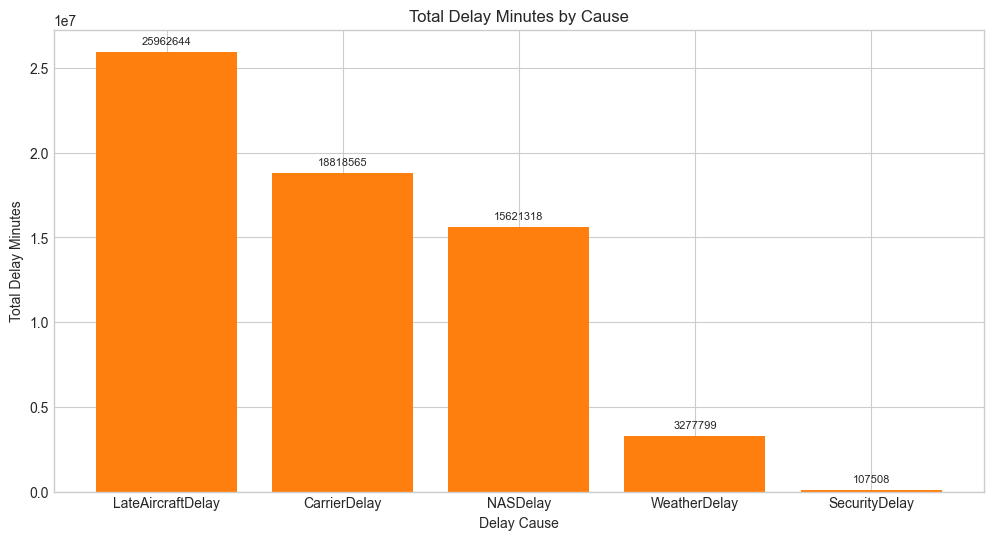

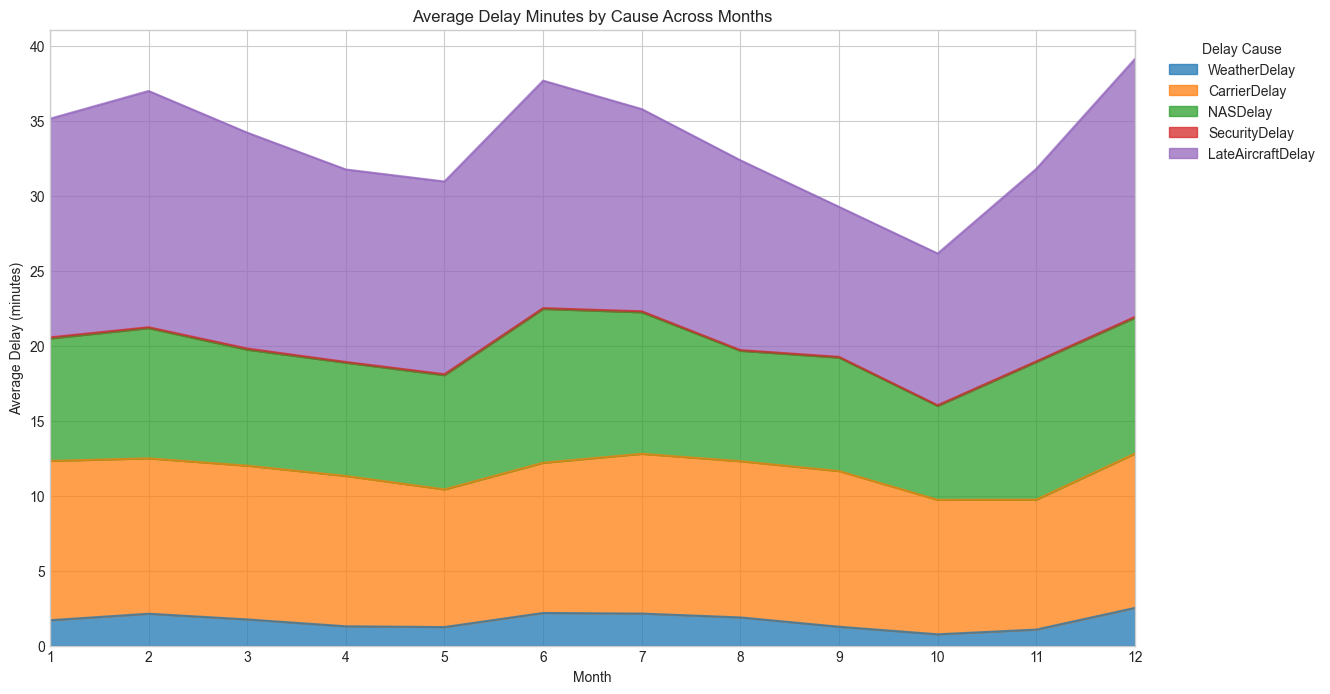

In [17]:
if delay_cause_cols:
    cause_summary = (
        df[delay_cause_cols]
        .sum()
        .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(cause_summary.index, cause_summary.values, color='tab:orange')
    ax.set_title('Total Delay Minutes by Cause')
    ax.set_xlabel('Delay Cause')
    ax.set_ylabel('Total Delay Minutes')
    annotate_bars(ax, fmt='{:.0f}')
    save_fig(fig, 'delay_cause_totals')
    plt.show()

    cause_month = (
        df[['Month'] + delay_cause_cols]
        .dropna(subset=['Month'])
        .groupby('Month')
        .mean()
        .reindex(range(1, 13), fill_value=0)
    )
    fig, ax = plt.subplots(figsize=(14, 8))
    cause_month.plot(kind='area', ax=ax, alpha=0.75)
    ax.set_title('Average Delay Minutes by Cause Across Months')
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Delay (minutes)')
    ax.set_xticks(range(1, 13))
    ax.set_xlim(1, 12)
    ax.legend(title='Delay Cause', bbox_to_anchor=(1.02, 1), loc='upper left')
    save_fig(fig, 'delay_cause_trends_by_month')
    plt.show()
else:
    print('No delay cause columns available in the dataset.')

**Insight:** Delay cause totals and seasonal cause composition reveal whether weather, NAS, late aircraft, or carrier operations are the dominant pain points. This informs whether interventions should focus on maintenance, crew scheduling, air traffic coordination, or weather preparedness.

## Delay distributions and carrier spreads

We visualize the distribution of arrival delays and compare the spread across top carriers.

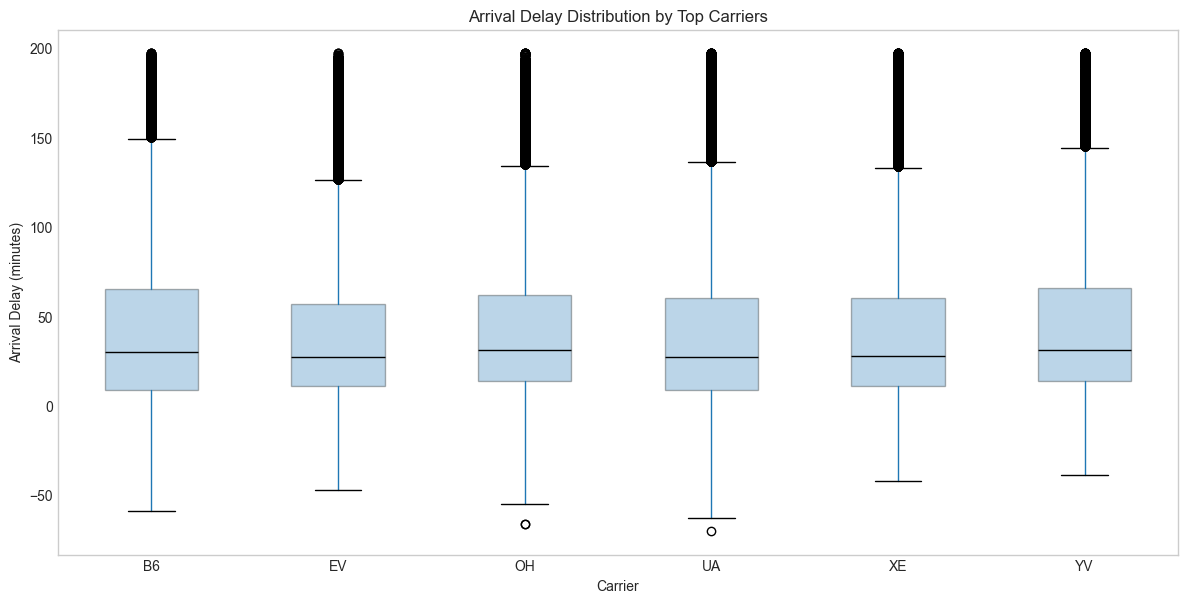

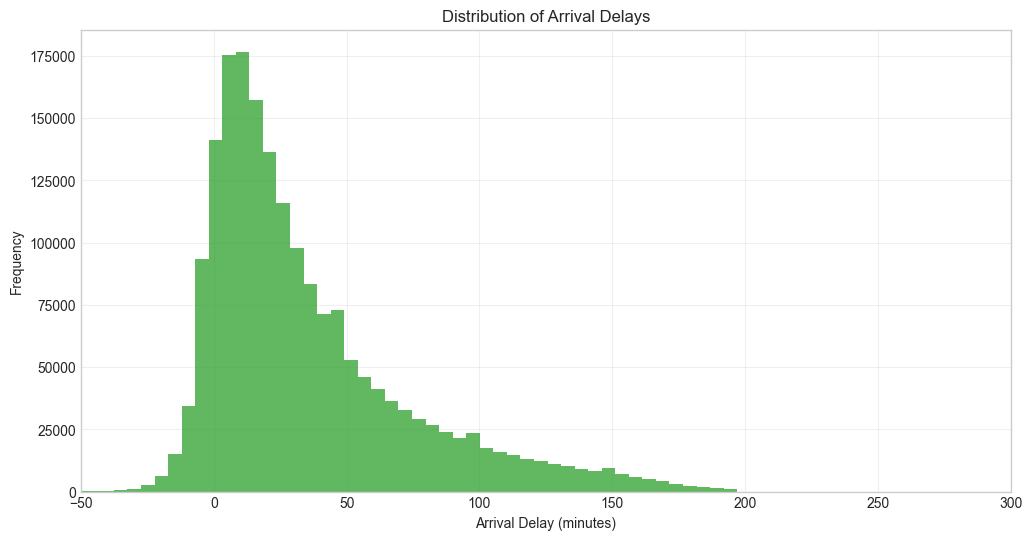

In [18]:
selected_carriers = carrier_stats.head(6).index.tolist()
subset = df[df['Carrier'].isin(selected_carriers) & df['ArrDelay'].notna()]

fig, ax = plt.subplots(figsize=(14, 7))
subset.boxplot(column='ArrDelay', by='Carrier', ax=ax, grid=False, patch_artist=True,
              boxprops=dict(facecolor='tab:blue', alpha=0.3), medianprops=dict(color='black'))
ax.set_title('Arrival Delay Distribution by Top Carriers')
ax.set_xlabel('Carrier')
ax.set_ylabel('Arrival Delay (minutes)')
plt.suptitle('')
save_fig(fig, 'carrier_delay_boxplot')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df['ArrDelay'].dropna(), bins=60, color='tab:green', alpha=0.75)
ax.set_title('Distribution of Arrival Delays')
ax.set_xlabel('Arrival Delay (minutes)')
ax.set_ylabel('Frequency')
ax.set_xlim(-50, 300)
ax.grid(True, alpha=0.3)
save_fig(fig, 'arrival_delay_distribution')
plt.show()

**Insight:** Delay spread shows whether carriers are consistently late or simply affected by rare large delays. A tight distribution around zero is usually a sign of stable operations, while a fat tail suggests occasional major disruptions.

## Departure delay vs arrival delay correlation

This scatter plot highlights how departure delay translates into arrival delay for each flight, showing propagation across the schedule.

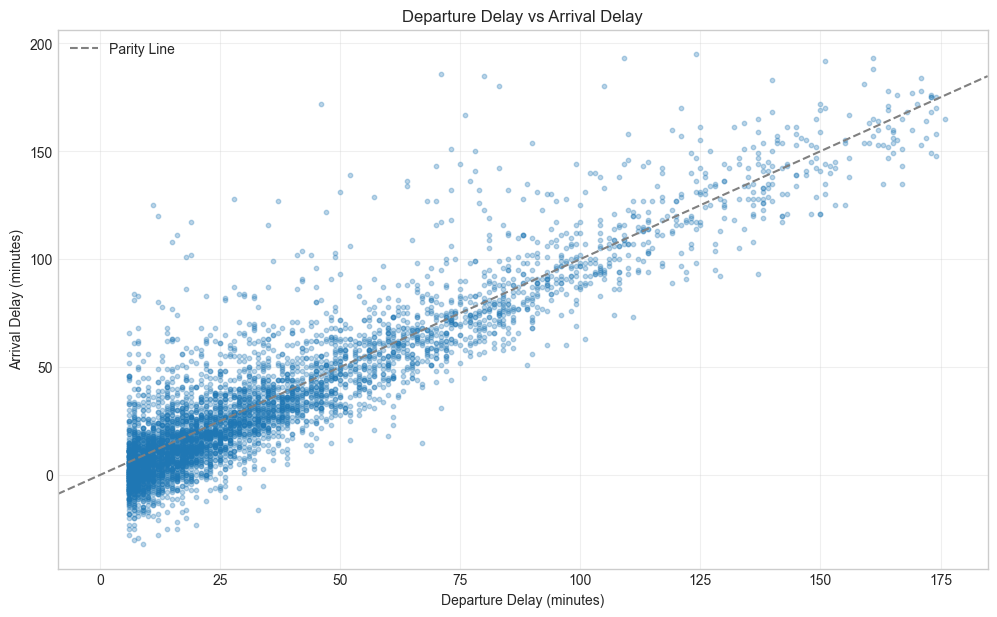

Correlation between DepDelay and ArrDelay: 0.910


In [19]:
prop_df = df[['DepDelay', 'ArrDelay']].dropna()
prop_sample = prop_df.sample(n=min(len(prop_df), 5000), random_state=42)
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(prop_sample['DepDelay'], prop_sample['ArrDelay'], alpha=0.3, s=10, color='tab:blue')
ax.set_title('Departure Delay vs Arrival Delay')
ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Arrival Delay (minutes)')
ax.axline((0, 0), slope=1, color='gray', linestyle='--', label='Parity Line')
ax.legend()
ax.grid(True, alpha=0.3)
save_fig(fig, 'dep_delay_vs_arr_delay')
plt.show()

correlation = prop_df.corr().loc['DepDelay', 'ArrDelay']
print(f'Correlation between DepDelay and ArrDelay: {correlation:.3f}')

**Insight:** A strong positive relationship between departure and arrival delay confirms propagation risk. When departure delays are not contained, they often carry into arrival performance and downstream disruption.